# Instalando as Bibliotecas Necessárias



In [1]:
# Installing the numpy, netcdf4, boto3 and gdal libraries
!pip install -q cartopy boto3 gdal salem rasterio pyproj geopandas descartes

# download do arquivo "utilities_goes16e19.py"
!wget -c https://github.com/evmpython/Minicurso_UFCG_nov_2025/raw/main/utils/utilities_goes16e19.py

# download da paleta de cores para o canal do infravermelho
!wget -c https://github.com/evmpython/Minicurso_UFCG_nov_2025/raw/main/utils/ir.cpt

# Monta drive
from google.colab import drive
drive.mount('/content/drive')

# Caminho do diretório
dir = '/content/drive/MyDrive/PYHTON/00_GITHUB/4_SATELITE/codigos_imagem_satelite_REFERENCIA'

# Diretório de Saída
import os
dir_output = f'{dir}/output/SAT_02'
os.makedirs(dir_output, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.7 MB/s eta 0:00:00
--2026-01-27 19:13:47--  https://github.com/evmpython/Minicurso_UFCG_nov_2025/raw/main/utils/utilities_goes16e19.py
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/evmpython/Minicurso_UFCG_nov_2025/main/utils/utilities_goes16e19.py [following]
--2026-01-27 19:13:47--  https://raw.gi

# Projeção Satélite em T-Realçada

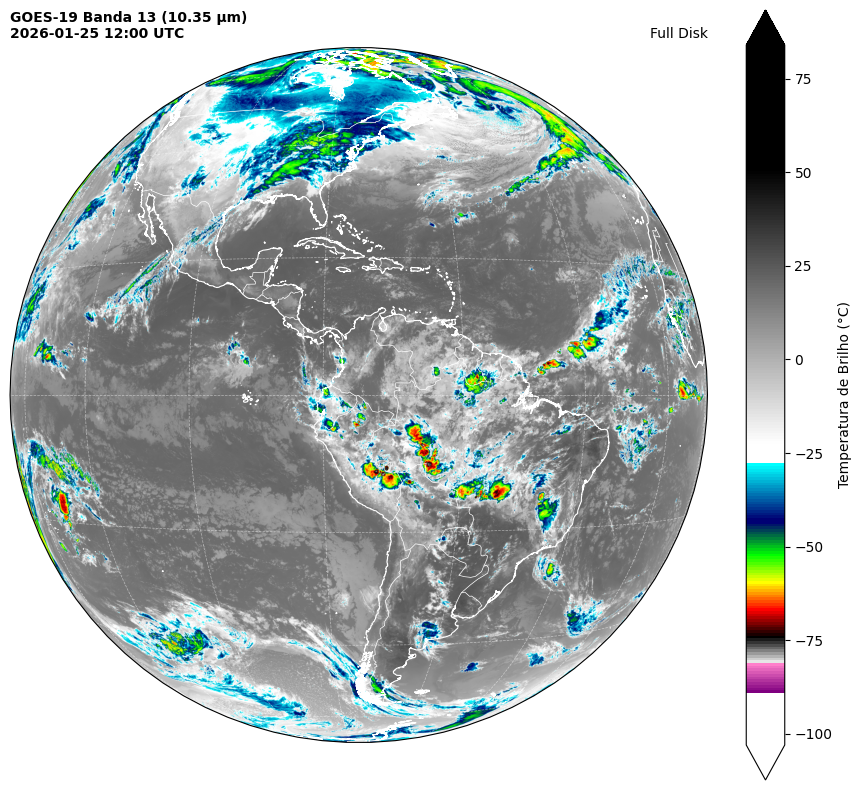

In [2]:
#========================================================================================================================#
#                                          IMPORTAÇÃO DAS BIBLIOTECAS
#========================================================================================================================#
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib import cm
import cartopy, cartopy.crs as ccrs
from datetime import datetime
from utilities_goes16e19 import download_CMI, remap, loadCPT
import os
import warnings
warnings.filterwarnings("ignore")

#========================================================================================================================#
#                                          CRIA DIRETÓRIO DE ENTRADA
#========================================================================================================================#
input = "/content/input"; os.makedirs(input, exist_ok=True)
output = dir_output

#========================================================================================================================#
#                                               DOWNLOAD DO ARQUIVO
#========================================================================================================================#
# data de processamento: 2024-04-30 às 18:00 UTC
yyyymmddhhmn = '202601251200'

# define o satélite GOES-16 ou GOES-19
start_g19 = datetime(2025,4,7,0,0)
imagem_atual = datetime.strptime(yyyymmddhhmn, '%Y%m%d%H%M')
goes_number = '16' if imagem_atual < start_g19 else '19'

# canal do ABI
band = '13'

# download do arquivo (CMI: "Cloud and Moisture Imagery" Product)
file_name = download_CMI(yyyymmddhhmn, band, goes_number, input)

# caminho do arquivo que foi baixado
path = f'{input}/{file_name}.nc'

#========================================================================================================================#
#                                               LEITURA DO ARQUIVO
#========================================================================================================================#
data = xr.open_dataset(path)

#========================================================================================================================#
#                                                 PLOTA A IMAGEM
#========================================================================================================================#
# tamanho da figura (largura x altura em polegadas)
plt.figure(figsize=(10,10))

# usa a projeção geoestacionária do cartopy
# para o GOES-16: longitude central: -75.0 / altura do satellite: 35786023.0
# a extensão do Full Disk: (metade dos pixels full disk) X (tamanho do pixel em radianos) X (altura do satélite em metros) => 2712 * 0.000056 * 35786023.0 = 5434894.67527
ax = plt.axes(projection=ccrs.Geostationary(central_longitude=-75.0, satellite_height=35786023.0))
img_extent = (-5434894.67527, 5434894.67527, -5434894.67527, 5434894.67527)

# linhas costeiras, bordas e linhas de grade do mapa
ax.coastlines(resolution='10m', color='white', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='white', linewidth=0.5)
ax.gridlines(color='white', alpha=0.5, linestyle='--', linewidth=0.5)

# converte o arquivo CPT para ser usado em Python
cpt = loadCPT('ir.cpt')
colormap = cm.colors.LinearSegmentedColormap('cpt', cpt)

# plota imagem
img = ax.imshow(data['CMI'] - 273.15, origin='upper', vmin=-103.0, vmax=84, extent=img_extent, cmap=colormap)

# barra de cores
plt.colorbar(img, label='Temperatura de Brilho (°C)', extend='both', orientation='vertical', pad=0.05, fraction=0.05)

# leitura da data/horário do arquivo NetCDF como uma string
date = (datetime.strptime(data.time_coverage_start, '%Y-%m-%dT%H:%M:%S.%fZ')).strftime('%Y-%m-%d %H:%M UTC')

# título da figura
plt.title(f'GOES-{goes_number} Banda {band} (10.35 µm)\n{date}', fontweight='bold', fontsize=10, loc='left')
plt.title('Full Disk', fontsize=10, loc='right')

# salva figura
plt.savefig(f'{output}/SAT_02_G{goes_number}_ch{band}_full_Trealcada_{date.replace(" ", "_")}.jpg', bbox_inches='tight', dpi=300)

# mostra figura na tela
plt.show()